**IE6400 Foundations Data Analytics Engineering**

**Fall Semester**

**Group Projects**

**Project 2**

**Topic: Customer Segmentation using RFM Analysis**

**1. Data Preprocessing:**

- Import the dataset and perform necessary data prrprocessing steps, including data cleaning, handling missing values, and converting data types if needed.

In [1]:
import pandas as pd
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
print(ed)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

             InvoiceDate  UnitPrice  CustomerID         Country  
0       1

In [2]:
#Displaying & Reading the first 10 rows of the dataset
ed.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12-01-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12-01-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12-01-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12-01-2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12-01-2010 08:34,1.69,13047.0,United Kingdom


In [3]:
#Identifying missing values in the dataset
ed.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
#Handling missing values in the dataset
ed['Description'].fillna('0', inplace=True)
ed['CustomerID'].fillna('0', inplace=True)
missing_data = ed.isnull().sum()
print(missing_data)

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [6]:
#Converting InvoiceDate to datetime format
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'], errors='coerce')
ed['Date'] = ed['InvoiceDate'].dt.date
ed['Time'] = ed['InvoiceDate'].dt.time
ed[['Date', 'Time']]

,Date,Time
0,2010-12-01,08:26:00
1,2010-12-01,08:26:00
2,2010-12-01,08:26:00
3,2010-12-01,08:26:00
4,2010-12-01,08:26:00
...,...,...
541904,2011-12-09,12:50:00
541905,2011-12-09,12:50:00
541906,2011-12-09,12:50:00
541907,2011-12-09,12:50:00


**2. RFM Calculation:**

- Calculate the RFM metrics for each customer

In [7]:
import pandas as pd
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
# Convert 'InvoiceDate' to datetime if not done yet
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'], errors='coerce')
# Calculate the total purchase amount for each transaction
ed['Amount'] = ed['Quantity'] * ed['UnitPrice']
# Set a reference date (typically the latest date in the data) to calculate Recency
reference_date = ed['InvoiceDate'].max()
# Initialize an empty RFM DataFrame and set CustomerID as the index
rfm = pd.DataFrame(index=ed['CustomerID'].unique())

# Calculate Recency
# For each customer, calculate days since last purchase
rfm['Recency'] = ed.groupby('CustomerID')['InvoiceDate'].max().apply(lambda x: (reference_date - x).days)

# Calculate Frequency
# Count unique invoices per customer
rfm['Frequency'] =ed.groupby('CustomerID')['InvoiceNo'].nunique()

# Calculate Monetary
# Sum the total spending for each customer
rfm['Monetary'] = ed.groupby('CustomerID')['Amount'].sum()

# Display the resulting RFM DataFrame
rfm.reset_index(inplace=True)  # Optional: Reset index to include CustomerID as a column
rfm.head(10)

,index,Recency,Frequency,Monetary
0,17850.0,301.0,35.0,5288.63
1,13047.0,31.0,18.0,3079.10
2,12583.0,2.0,18.0,7187.34
3,13748.0,95.0,5.0,948.25
4,15100.0,333.0,6.0,635.10
5,15291.0,31.0,20.0,4596.51
6,14688.0,7.0,27.0,5107.38
7,17809.0,60.0,15.0,4627.62
8,15311.0,0.0,118.0,59419.34
9,14527.0,2.0,86.0,7711.38


- **Recency (R):** How recently a customer made a purchase. Calculate the number of days since the customer's last purchase.

In [8]:
import pandas as pd
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
# Ensure InvoiceDate is in datetime format
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'], errors='coerce')
# Set the reference date (latest date in the dataset)
reference_date = ed['InvoiceDate'].max()
# Calculate the last purchase date for each customer
recency_df = ed.groupby('CustomerID').agg(LastPurchase=('InvoiceDate', 'max')).reset_index()
# Calculate recency as the number of days since the last purchase
recency_df['Recency'] = (reference_date - recency_df['LastPurchase']).dt.days
# Display the results
print("Recency Table:")
print(recency_df.head())

Recency Table:
   CustomerID        LastPurchase  Recency
0     12346.0                 NaT      NaN
1     12347.0 2011-12-07 15:52:00      1.0
2     12348.0 2011-04-05 10:47:00    248.0
3     12349.0                 NaT      NaN
4     12350.0 2011-02-02 16:01:00    309.0


- **Frequency (F):** How often a customer makes a purchase. Calculate the total number of orders for each customer.

In [9]:
import pandas as pd
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
# Calculate Frequency: Count the unique 'InvoiceNo' for each customer
frequency_df = ed.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique'
}).reset_index()

# Rename 'InvoiceNo' to 'Frequency' 
frequency_df.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)
# Display the Frequency values
frequency_df.head(10)

,CustomerID,Frequency
0,12346.0,2
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
5,12352.0,11
6,12353.0,1
7,12354.0,1
8,12355.0,1
9,12356.0,3


- **Monetary (M):** The total monetary value of a customer's purchases. Calculate the sum of the total price for each customer.

In [10]:
import pandas as pd
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
#Calculate the total purchase amount for each transaction
ed['Amount'] = ed['Quantity'] * ed['UnitPrice']
# Calculate Monetary: Sum the 'Amount' for each customer using pivot_table
monetary_df = ed.pivot_table(
    index='CustomerID',
    values='Amount',
    aggfunc='sum'
).reset_index()
# Rename the 'Amount' column to 'Monetary'
monetary_df.rename(columns={'Amount': 'Monetary'}, inplace=True)
# Display the Monetary values
monetary_df.head(10)

,CustomerID,Monetary
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
5,12352.0,1545.41
6,12353.0,89.00
7,12354.0,1079.40
8,12355.0,459.40
9,12356.0,2811.43


**3. RFM Segmentation:**

- Assign RFM scores to each customer based on their quartiles (or custom-defined bins). You can use quartiles (1 to 4) or custom scores (e.g., 1 to 5) for each RFM metric.

In [11]:
import pandas as pd
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
# Convert 'InvoiceDate' to datetime 
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'], errors='coerce')
# Calculate the total purchase amount for each transaction
ed['Amount'] = ed['Quantity'] * ed['UnitPrice']
# Calculate the total price for each transaction
ed['Amount'] = ed['Quantity'] * ed['UnitPrice']
# Drop rows with null values
ed.dropna(inplace=True)
# Set a reference date (typically the latest date in the dataset)
reference_date = ed['InvoiceDate'].max()
# Calculate Recency, Frequency, and Monetary metrics for each customer
rfm = ed.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Amount': 'sum'                                            # Monetary
}).reset_index()
# Rename columns 
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Amount': 'Monetary'
}, inplace=True)
# Define custom bins and labels
# Recency Score: Lower recency gets a higher score
recency_bins = [0, 30, 90, 180, rfm['Recency'].max()]
rfm['R_Score'] = pd.cut(rfm['Recency'], bins=recency_bins, labels=[4, 3, 2, 1], right=False)
# Frequency Score: Higher frequency gets a higher score
frequency_bins = [0, 2, 5, 10, rfm['Frequency'].max()]
rfm['F_Score'] = pd.cut(rfm['Frequency'], bins=frequency_bins, labels=[1, 2, 3, 4], right=False)
# Monetary Score: Higher monetary value gets a higher score
monetary_bins = [0, 100, 500, 1000, rfm['Monetary'].max()]
rfm['M_Score'] = pd.cut(rfm['Monetary'], bins=monetary_bins, labels=[1, 2, 3, 4], right=False)
# Combine the RFM scores into a single 'RFM_Score' column
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


# Print interpretation for RFM scores (1 to 4) for Recency, Frequency, and Monetary
print("\nInterpretation of RFM scores:")
print("Recency (R) Score:")
print("4: Customer made a very recent purchase")
print("3: Customer purchased fairly recently")
print("2: Customer's last purchase was somewhat recent")
print("1: Customer has not made a purchase in a long time\n")

print("Frequency (F) Score:")
print("4: Customer has made many purchases")
print("3: Customer has made a moderate number of purchases")
print("2: Customer has made a few purchases")
print("1: Customer has made very few purchases\n")

print("Monetary (M) Score:")
print("4: Customer has spent a high amount overall")
print("3: Customer has spent a moderately high amount")
print("2: Customer has spent a moderate amount")
print("1: Customer has spent a low amount overall")

# Display the cleaned data and RFM scores
print("Cleaned data with RFM metrics:")
print(rfm.head(10))


Interpretation of RFM scores:
Recency (R) Score:
4: Customer made a very recent purchase
3: Customer purchased fairly recently
2: Customer's last purchase was somewhat recent
1: Customer has not made a purchase in a long time

Frequency (F) Score:
4: Customer has made many purchases
3: Customer has made a moderate number of purchases
2: Customer has made a few purchases
1: Customer has made very few purchases

Monetary (M) Score:
4: Customer has spent a high amount overall
3: Customer has spent a moderately high amount
2: Customer has spent a moderate amount
1: Customer has spent a low amount overall
Cleaned data with RFM metrics:
   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0     12347.0        1          5   2540.29       4       3       4       434
1     12348.0      248          1    367.00       1       1       2       112
2     12350.0      309          1    334.40       1       1       2       112
3     12352.0       35          5    456.08     

- Combine the RFM scores to create a single RFM score for each customer.

In [12]:
# Convert R, F, M scores to integers while handling NaNs by using the 'Int64' dtype (pandas nullable integer type)
rfm['R_Score'] = rfm['R_Score'].astype('Int64').fillna(0)
rfm['F_Score'] = rfm['F_Score'].astype('Int64').fillna(0)
rfm['M_Score'] = rfm['M_Score'].astype('Int64').fillna(0)
# Concatenated RFM Score 
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
# Display concatenated RFM Score
print("Concatenated RFM Score :")
print(rfm[['CustomerID', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head())
# Weighted Average RFM Score
# Define weights based on business needs
weight_recency = 0.3
weight_frequency = 0.5
weight_monetary = 0.2
# Calculate weighted RFM score
rfm['Weighted_RFM_Score'] = (
    rfm['R_Score'] * weight_recency +
    rfm['F_Score'] * weight_frequency +
    rfm['M_Score'] * weight_monetary
)
# Display the weighted RFM score
print("\nWeighted Average RFM Score:")
print(rfm[['CustomerID', 'R_Score', 'F_Score', 'M_Score', 'Weighted_RFM_Score']].head())


Concatenated RFM Score :
   CustomerID  R_Score  F_Score  M_Score RFM_Score
0     12347.0        4        3        4       434
1     12348.0        1        1        2       112
2     12350.0        1        1        2       112
3     12352.0        3        3        2       332
4     12355.0        1        1        2       112

Weighted Average RFM Score:
   CustomerID  R_Score  F_Score  M_Score  Weighted_RFM_Score
0     12347.0        4        3        4                 3.5
1     12348.0        1        1        2                 1.2
2     12350.0        1        1        2                 1.2
3     12352.0        3        3        2                 2.8
4     12355.0        1        1        2                 1.2


**4. Customer Segmentation:**

- Use clustering techniques (e.g., K-Means clustering) to segment customers based on their RFM scores.

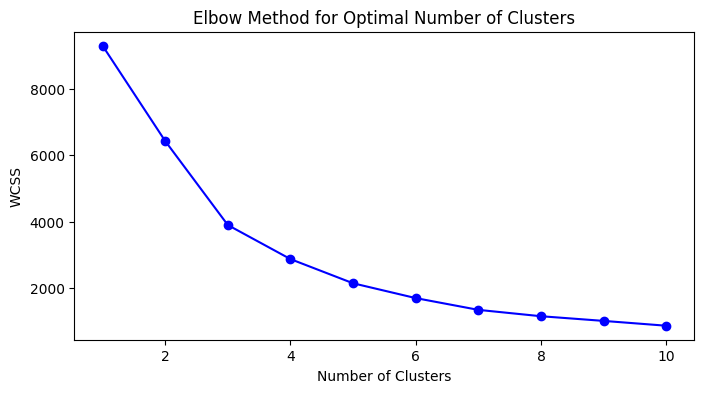

Cluster Summary (Mean RFM values and Customer Count):
            Recency   Frequency       Monetary  CustomerCount
Cluster                                                      
0         43.908040    6.656281    2080.088825           1990
1        255.718363    3.286394     923.753788           1051
2          2.000000  110.500000  213995.575000              4
3          7.269231   55.711538   32024.793077             52


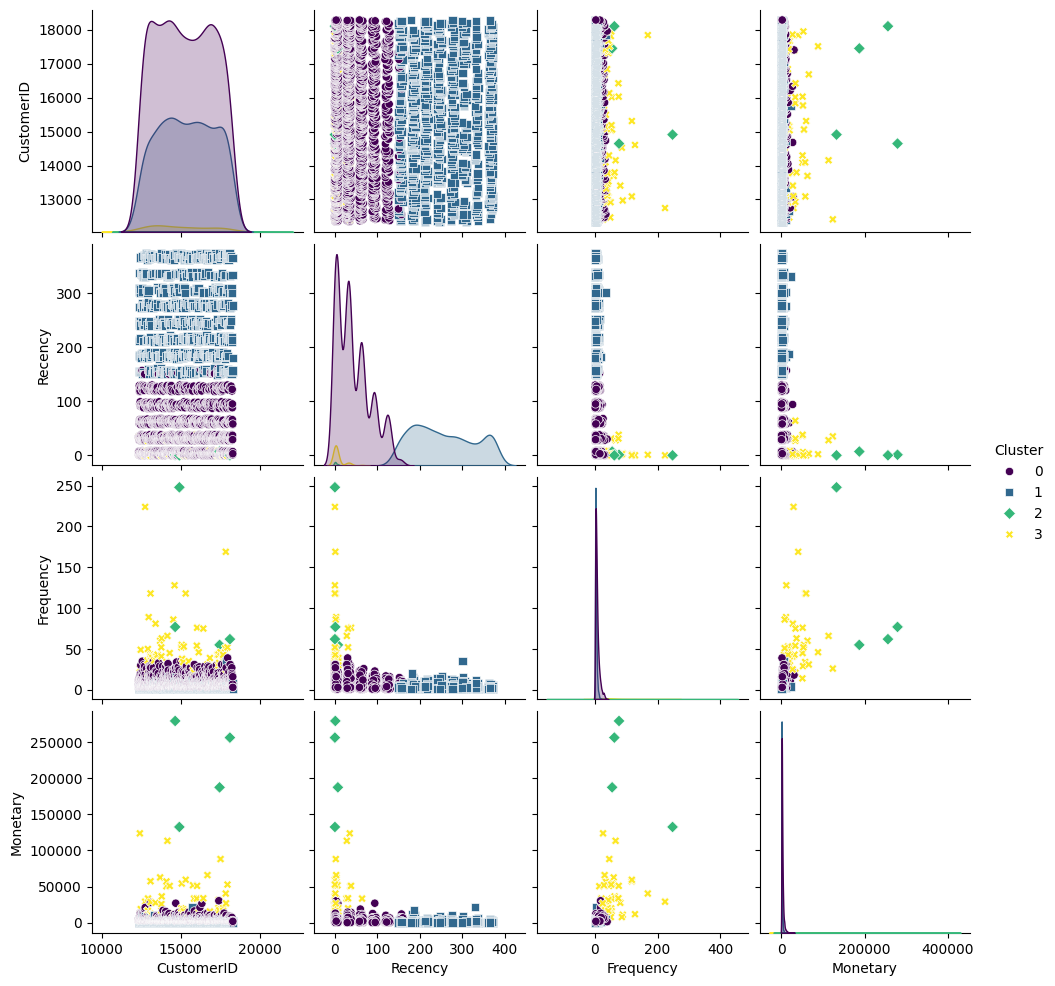

In [18]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")

# Drop null values
ed.dropna(inplace=True)

# Convert 'InvoiceDate' to datetime and calculate Amount
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'], errors='coerce')
ed['Amount'] = ed['Quantity'] * ed['UnitPrice']

# Set reference date for Recency calculation
reference_date = ed['InvoiceDate'].max()

# Calculate RFM metrics
rfm = ed.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Amount': 'sum'                                            # Monetary
}).reset_index()

# Rename columns
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'Amount': 'Monetary'}, inplace=True)

# Handle missing or invalid values in RFM metrics
rfm = rfm.dropna()
rfm = rfm[(rfm['Recency'] >= 0) & (rfm['Frequency'] > 0) & (rfm['Monetary'] > 0)]

# Scale RFM data for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Check for NaN or extreme values in scaled data
if np.isnan(rfm_scaled).any():
    print("NaN values found in scaled data. Please check your input dataset.")
    raise ValueError("NaN values found in scaled data.")
if np.isinf(rfm_scaled).any():
    print("Infinity values found in scaled data. Please check your input dataset.")
    raise ValueError("Infinity values found in scaled data.")

# Find the optimal number of clusters using the Elbow Method
wcss = []  # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Choose an appropriate number of clusters (e.g., based on the elbow point) and fit K-Means
optimal_clusters = 4  # Example: Select 4 clusters based on the elbow method
kmeans = KMeans(n_clusters=optimal_clusters, random_state=0)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Analyze and interpret each cluster
# Calculate mean RFM values for each cluster
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'})

print("Cluster Summary (Mean RFM values and Customer Count):")
print(cluster_summary)

# Visualize clusters using a pair plot
sns.pairplot(rfm, hue='Cluster', palette='viridis', markers=["o", "s", "D", "X"])
plt.show()


- Experiment with different numbers of clusters to find the optimal number that provides meaningful segments.

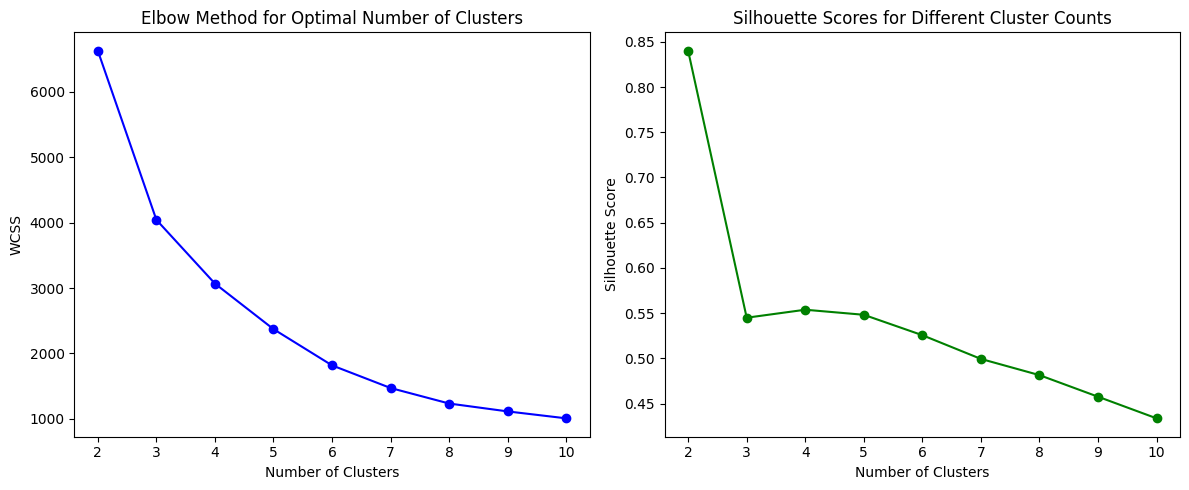

In [19]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
ed.dropna(inplace=True)
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'], errors='coerce')
ed['Amount'] = ed['Quantity'] *ed['UnitPrice']
reference_date = ed['InvoiceDate'].max()

# Calculate RFM metrics
rfm = ed.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Amount': 'sum'                                            # Monetary
}).reset_index()
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'Amount': 'Monetary'}, inplace=True)

# Scale the RFM data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Initialize lists to store the WCSS and silhouette scores for each cluster count
wcss = []
silhouette_scores = []

# Experiment with cluster counts from 2 to 10
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(rfm_scaled)
    
    # Append WCSS and silhouette score
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))
# Plot WCSS (Elbow Method) and Silhouette Scores
plt.figure(figsize=(12, 5))

# Elbow Method plot
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

# Silhouette Score plot
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-', color='g')
plt.title('Silhouette Scores for Different Cluster Counts')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

**5. Segment Profiling:**

- Analyze and profile each customer segment. Describe the characteristics of customers in each segment, including their RFM scores and any other relevant attributes.

In [24]:
# Calculate RFM metrics
rfm = ed.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'Amount': 'sum'                                            # Monetary
}).reset_index()
# Rename columns
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'Amount': 'Monetary'}, inplace=True)
# Handle missing or invalid values in RFM metrics
rfm = rfm.dropna()
rfm = rfm[(rfm['Recency'] >= 0) & (rfm['Frequency'] > 0) & (rfm['Monetary'] > 0)]
# Scale RFM data for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=0)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Verify that the Cluster column exists
print(rfm.head())  # Ensure the 'Cluster' column is present

# Calculate mean RFM values for each cluster
rfm_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()

# Calculate customer count for each cluster
customer_counts = rfm.groupby('Cluster').agg({
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'}).reset_index()

# Display results
print("Cluster Summary (Mean RFM values):")
print(rfm_summary)
print("\nCustomer Count in Each Cluster:")
print(customer_counts)

   CustomerID  Recency  Frequency  Monetary  Cluster
0     12347.0        1          5   2540.29        0
1     12348.0      248          1    367.00        1
2     12350.0      309          1    334.40        1
3     12352.0       35          5    456.08        0
4     12355.0      213          1    459.40        1
Cluster Summary (Mean RFM values):
   Cluster     Recency  Frequency       Monetary
0        0   43.869005   3.345539    1054.107942
1        1  256.334347   1.509625     439.610284
2        2    0.500000  29.000000  111762.715000
3        3   13.574468  27.787234   17761.548085

Customer Count in Each Cluster:
   Cluster  CustomerCount
0        0           1939
1        1            987
2        2              2
3        3             47


**6. Marketing Recommendations:**

- Provide actionable marketing recommendations for each customer segment. How can the business tailor its marketing strategies for each group to improve customer retention and maximize revenue?

To maximize revenue and improve customer retention, the business can develop targeted marketing strategies for each customer segment identified through RFM segmentation. Here are some actionable marketing recommendations based on typical characteristics of each segment:
1. High-Value Clients (High Monetary, High Frequency, Low Recency) Features: These clients spend a lot of money on average,      buy often, and have just made a purchase. They are precious and devoted. Suggestions: Loyalty Programs: To encourage these    clients to keep making purchases, put in place a loyalty or rewards program. VIP Access & special Offers: Provide VIP-only    discounts, early access to new items, or invitations to special events. Personalized Cross-Selling/Upselling: To boost        order value, send customized suggestions for related items.

2. Dedicated Clients with Moderate Recency (High Frequency, Moderate to High Monetary, Moderate Recency) Features: These         clients are frequent buyers with moderate purchase values, but they haven't made any recent purchases. Suggestions: Re-       engagement Offers: To entice a repeat purchase, provide customized discounts or time-limited deals. Product Suggestions       and Reminders: Provide personalized suggestions based on their prior purchases or "back in stock" alerts for items they       have already looked at. Offers for Subscriptions or Bundling: To boost convenience and purchase frequency, advertise          subscription services or bundled product offers.

3. Customers at Risk (Moderate Frequency, Moderate Monetary, High Recency) Features: Although they haven't made a recent         purchase and don't buy as often, these customers have previously purchased products, suggesting some brand familiarity.       Suggestions: Win-Back Initiatives: Send customized win-back campaigns that provide exclusive deals or discounts. Feedback     Survey: Ask about prior experiences to find out why they might not be coming back, and as a thank you, give them a            discount. Emphasize New Products: To pique interest and remind customers of the company, highlight new products, seasonal     collections, or well-liked items.

4. Customers that are new or infrequent (high recency, low frequency, low monetary) Features: These clients are either brand-    new or spend little money on goods. Suggestions: Campaigns for Welcome and Nurture: Create a series of introductory emails    for prospective clients that highlight the brand, product lines, and special selling points. Discounts on Next Purchase:      To promote repeat business and foster brand loyalty, give them a discount on their subsequent purchases. Educational          Content: To establish credibility and show the benefits of making more frequent purchases, provide product manuals, how-to    videos, or client endorsements.

5. Potential Loyalists (if any, according to the Low Recency, Moderate Frequency, Moderate Monetary RFM classification)          Features: This segment's customers have a history of modest spending and just completed a transaction. They have the          potential to become valuable clients. Suggestions: Promote Regularity: Provide a temporary discount or package offers to      entice customers to make more regular purchases. Increase Brand Involvement: To increase brand loyalty, send testimonials,    customer success stories, and brand tales. Targeted Product Suggestions: Based on past purchases, present them with           related goods they might find interesting. Overarching Plans for Every Segment: Personalization: Based on previous            actions, use consumer data to tailor marketing messages and ensure their relevancy. Customer Journey Mapping: Keep track      of the phases of the customer journey to deliver experiences, offers, and messages that are specific to each stage.           Frequent Engagement: To keep consumers interested, stay in touch with them via email and social media and provide timely,     pertinent information. By matching the marketing strategy to the unique demands and habits of each customer group, these      tactics can improve customer happiness, retention, and lifetime value for each segment.


**7. Visualization:**

- Create visualizations (e.g., bar charts, scatter plots, or heat maps) to illustrate the RFM distribution and the clusters formed.

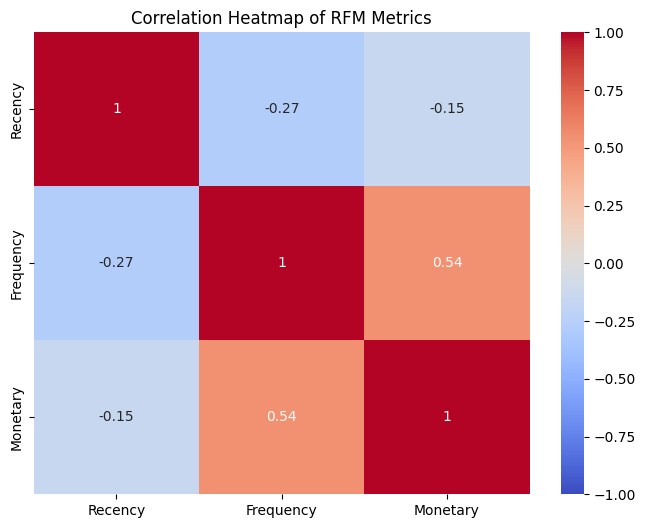

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for RFM metrics
rfm_metrics = rfm[['Recency', 'Frequency', 'Monetary']]
correlation_matrix = rfm_metrics.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of RFM Metrics')
plt.show()

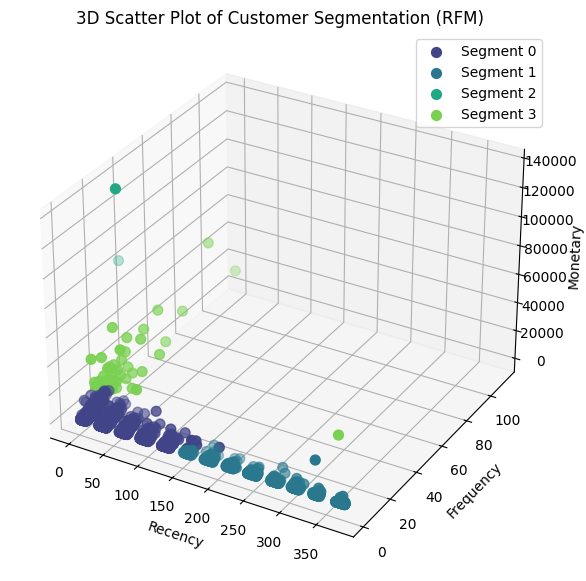

In [26]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors = sns.color_palette('viridis', n_colors=optimal_clusters)

for cluster in range(optimal_clusters):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    ax.scatter(cluster_data['Recency'], cluster_data['Frequency'], cluster_data['Monetary'],
               label=f'Segment {cluster}', color=colors[cluster], s=50)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('3D Scatter Plot of Customer Segmentation (RFM)')
plt.legend()
plt.show()

**1. Data Overview:**

- What is the size of the dataset in terms of the number of rows and columns?

In [27]:
import pandas as pd
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
print(f"Dataset Size: {ed.shape}")

Dataset Size: (541909, 8)


- Can you provide a brief description of each column in the dataset?

In [28]:
print("\nColumn Descriptions:")
print(ed.info())

print("\nSummary Statistics for Numerical Columns:")
print(ed.describe())


Column Descriptions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

Summary Statistics for Numerical Columns:
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000 

- What is the period covered by this dataset?

In [29]:
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'], errors='coerce')
start_date = ed['InvoiceDate'].min()
end_date = ed['InvoiceDate'].max()

print("Period covered by the dataset:")
print("Start Date:", start_date)
print("End Date:", end_date)

Period covered by the dataset:
Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


**2. Customer Analysis:**

- How many unique customers are there in the dataset?

In [30]:
unique_customers = ed['CustomerID'].nunique()
print("Number of unique customers:", unique_customers)

Number of unique customers: 4372


- What is the distribution of the number of orders per customer?

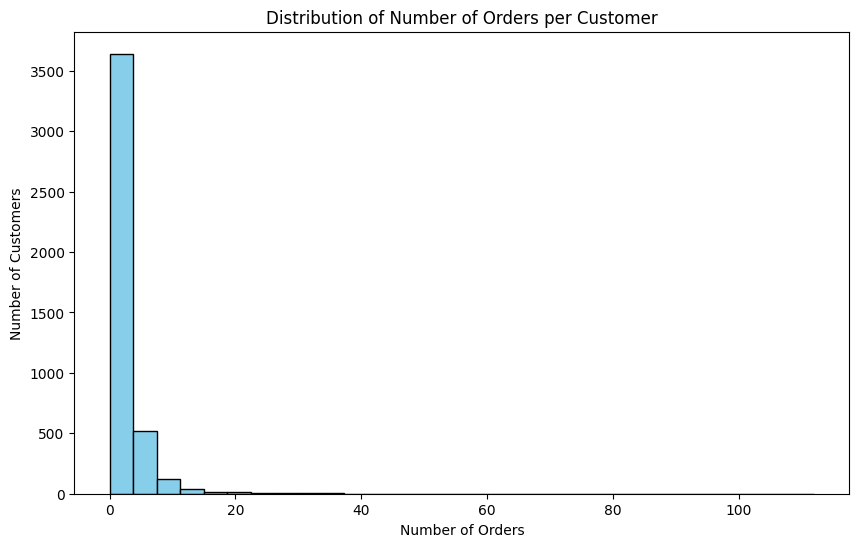

In [31]:
# Group by customer ID and count the number of unique orders per customer
order_counts = ed.groupby('CustomerID')['InvoiceDate'].nunique()
# Plot the distribution of order counts per customer
plt.figure(figsize=(10, 6))
order_counts.plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Number of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

- Can you identify the top 5 customers who have made the most purchases by order count?

In [32]:
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
# Group by customer ID and count the number of unique orders per customer
order_counts = ed.groupby('CustomerID')['InvoiceNo'].nunique()

# Identify the top 5 customers with the most purchases
top_customers = order_counts.nlargest(5)
print("Top 5 customers with the most purchases:")
print(top_customers)

Top 5 customers with the most purchases:
CustomerID
14911.0    248
12748.0    224
17841.0    169
14606.0    128
13089.0    118
Name: InvoiceNo, dtype: int64


**3. Product Analysis:**

- What are the top 10 most frequently purchased products?

In [34]:
# Count the frequency of each product being purchased
product_counts = ed['StockCode'].value_counts()
# Get the top 10 most frequently purchased products
top_products = product_counts.head(10)
print("Top 10 most frequently purchased products:")
print(top_products)

Top 10 most frequently purchased products:
StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
84879     1502
22720     1477
22197     1476
21212     1385
20727     1350
Name: count, dtype: int64


- What is the average price of products in the dataset?

In [35]:
# Calculate the average price of products
average_price = ed['UnitPrice'].mean()
print("Average price of products:", average_price)

Average price of products: 4.611113626088513


- Can you find out which product category generates the highest revenue?

In [36]:
# Calculate revenue for each row
ed['revenue'] = ed['UnitPrice'] * ed['Quantity']
# Group by product category and sum up the revenue for each category
category_revenue = ed.groupby('Description')['revenue'].sum()
# Identify the category with the highest revenue
top_category = category_revenue.idxmax()
highest_revenue = category_revenue.max()

print("Product category with the highest revenue:")
print("Category:", top_category)
print("Revenue:", highest_revenue)

Product category with the highest revenue:
Category: DOTCOM POSTAGE
Revenue: 206245.48


**4. Time Analysis:**

- Is there a specific day of the week or time of day when most orders are placed?

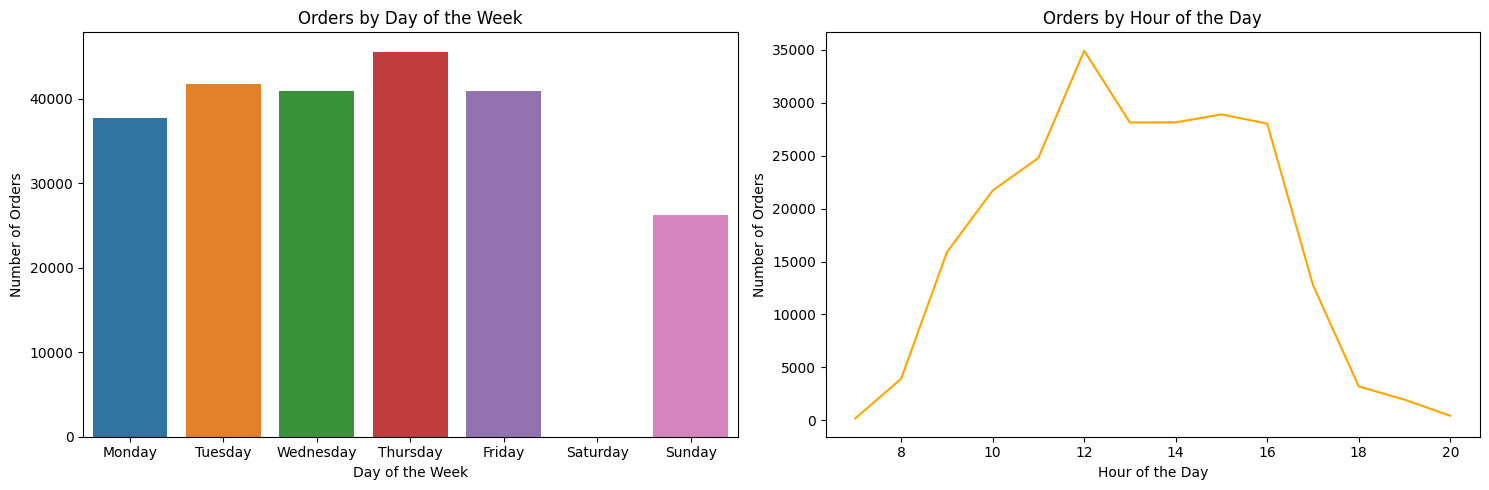

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
ed = pd.read_csv(r"C:\project2\IE6400\ecommercedata.csv")
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'], errors='coerce')
# Assume `ed` is your DataFrame and has a column 'InvoiceDate' with datetime information
# Extract day of the week and hour from 'InvoiceDate'
ed['DayOfWeek'] = ed['InvoiceDate'].dt.day_name()
ed['Hour'] = ed['InvoiceDate'].dt.hour
# Group by day of the week to see order patterns by day
day_counts = ed.groupby('DayOfWeek').size().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
# Group by hour to see order patterns by time of day
hour_counts = ed.groupby('Hour').size()

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Plot day of week without the deprecated palette usage
sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[0], hue=day_counts.index, dodge=False, legend=False)
axes[0].set_title('Orders by Day of the Week')
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Number of Orders')

# Plot hour of day
sns.lineplot(x=hour_counts.index, y=hour_counts.values, ax=axes[1], color='orange')
axes[1].set_title('Orders by Hour of the Day')
axes[1].set_xlabel('Hour of the Day')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

- What is the average order processing time?

Average Time Between Orders: 1.83 days


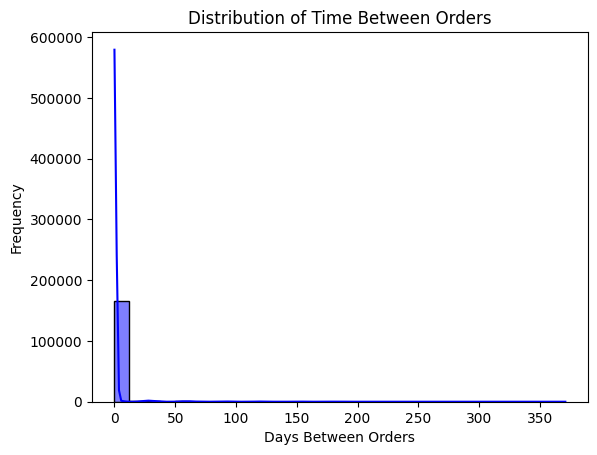

In [38]:
# Ensure 'InvoiceDate' is in datetime format
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'])
# Sort data by CustomerID and InvoiceDate
ed = ed.sort_values(by=['CustomerID', 'InvoiceDate'])
# Calculate time difference between consecutive orders for each customer
ed['TimeDiff'] = ed.groupby('CustomerID')['InvoiceDate'].diff().dt.days
# Calculate the average processing time (ignoring NaN for the first order of each customer)
avg_processing_time = ed['TimeDiff'].mean()

# Display the result
print(f"Average Time Between Orders: {avg_processing_time:.2f} days")
sns.histplot(ed['TimeDiff'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of Time Between Orders')
plt.xlabel('Days Between Orders')
plt.ylabel('Frequency')
plt.show()

- Are there any seasonal trends in the dataset?

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Ensure InvoiceDate is in datetime format
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'])

# Extract temporal features
ed['Year'] = ed['InvoiceDate'].dt.year
ed['Month'] = ed['InvoiceDate'].dt.month
ed['DayOfWeek'] = ed['InvoiceDate'].dt.dayofweek
ed['MonthName'] = ed['InvoiceDate'].dt.month_name()
ed['DayName'] = ed['InvoiceDate'].dt.day_name()

# Define seasons based on months
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

ed['Season'] = ed['Month'].apply(get_season)

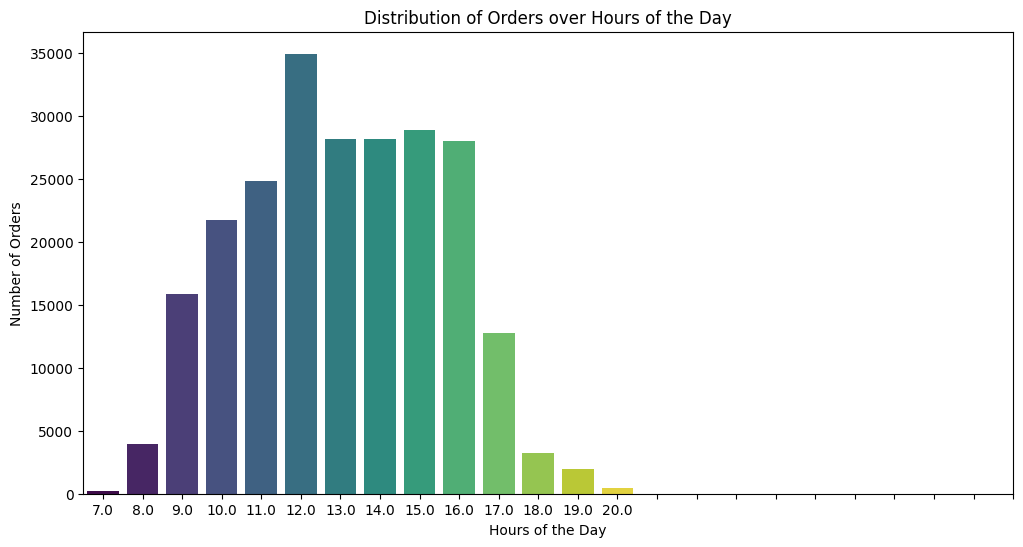

In [40]:
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'])
# Create 'HoursOfDay' column
ed['HoursOfDay'] = ed['InvoiceDate'].dt.hour
# Plot the distribution of orders over hours of the day
plt.figure(figsize=(12, 6))
sns.countplot(x='HoursOfDay', data=ed, hue='HoursOfDay', legend=False,  palette='viridis')
plt.title('Distribution of Orders over Hours of the Day')
plt.xlabel('Hours of the Day')
plt.ylabel('Number of Orders')
plt.xticks(range(24))  # Ensure all hours are shown on the x-axis
plt.show()

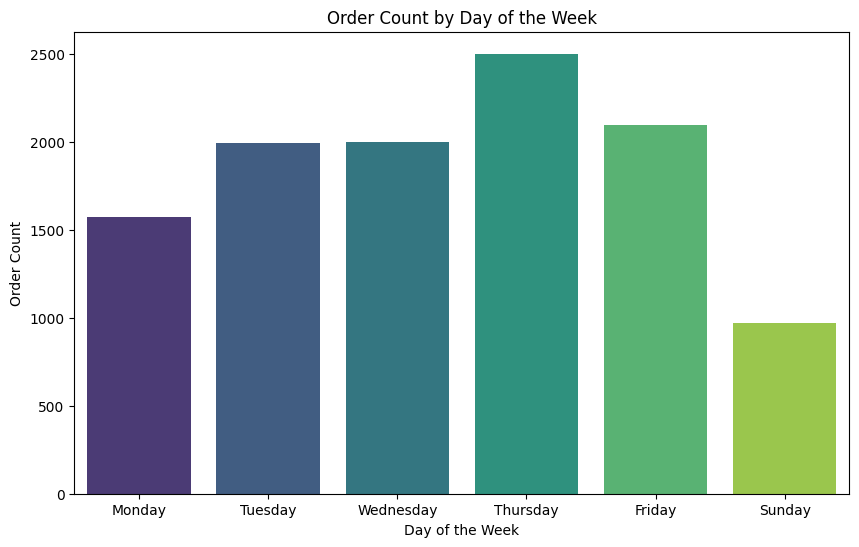

In [41]:
# Aggregate data by day of the week
weekly_data = ed.groupby('DayOfWeek').agg({'InvoiceNo': 'nunique', 'Quantity': 'sum'}).reset_index()
weekly_data = weekly_data.rename(columns={'InvoiceNo': 'OrderCount', 'Quantity': 'TotalQuantity'})
# Map day indices to names
day_mapping = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekly_data['DayName'] = weekly_data['DayOfWeek'].map(day_mapping)
# Plot weekly trends
plt.figure(figsize=(10, 6))
sns.barplot(data=weekly_data, x='DayName', y='OrderCount',hue='DayName', palette='viridis')
plt.title('Order Count by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Order Count')
plt.show()

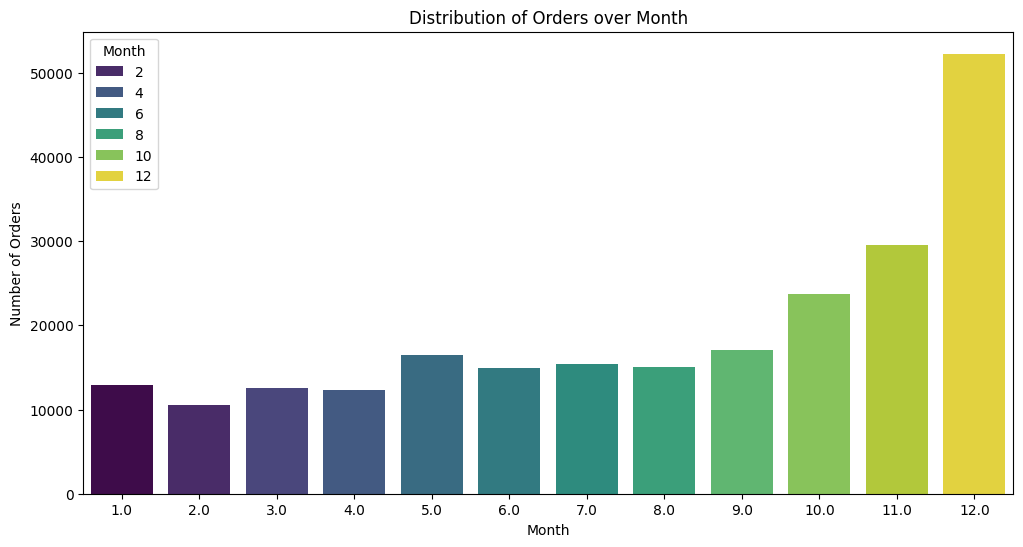

In [42]:
# Convert 'InvoiceDate' to datetime if it's not already
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'])
# Extract the 'Month' column (optional if already exists)
ed['Month'] = ed['InvoiceDate'].dt.month
# Plot the distribution of orders over months
plt.figure(figsize=(12, 6))
sns.countplot(x='Month', hue='Month', data=ed, palette='viridis')
plt.title('Distribution of Orders over Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

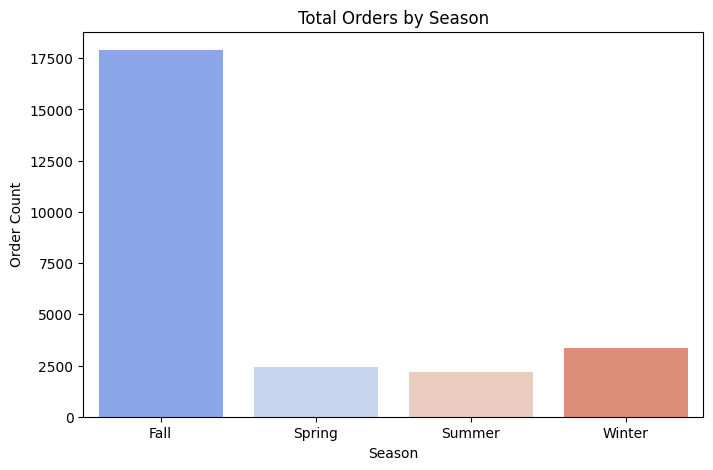

In [43]:
# Aggregate data by season
seasonal_data = ed.groupby('Season').agg({'InvoiceNo': 'nunique', 'Quantity': 'sum'}).reset_index()
seasonal_data = seasonal_data.rename(columns={'InvoiceNo': 'OrderCount', 'Quantity': 'TotalQuantity'})
# Plot seasonal trends
plt.figure(figsize=(8, 5))
sns.barplot(data=seasonal_data, x='Season', y='OrderCount', hue='Season', palette='coolwarm')
plt.title('Total Orders by Season')
plt.xlabel('Season')
plt.ylabel('Order Count')
plt.show()

**5. Geographical Analysis:**

- Can you determine the top 5 countries with the highest number of orders?

In [44]:
# Count the number of unique orders per country
country_order_count = ed.groupby('Country')['InvoiceNo'].nunique().reset_index()
# Rename columns for clarity
country_order_count = country_order_count.rename(columns={'InvoiceNo': 'OrderCount'})
# Sort the countries by the number of orders in descending order
top_5_countries = country_order_count.sort_values(by='OrderCount', ascending=False).head(5)
# Reset the index for clean output
top_5_countries = top_5_countries.reset_index(drop=True)

# Display the result
print("Top 5 Countries with the Highest Number of Orders:")
print(top_5_countries.to_string(index=False))

Top 5 Countries with the Highest Number of Orders:
       Country  OrderCount
United Kingdom       23494
       Germany         603
        France         461
          EIRE         360
       Belgium         119


- Is there a correlation between the customer's country and the average order value?

Average Order Value (AOV) by Country:
                 Country          AOV
24           Netherlands  2818.431089
0              Australia  1986.627101
21               Lebanon  1693.880000
20                 Japan  1262.165000
4                 Brazil  1143.600000
28                   RSA  1002.310000
30             Singapore   912.039000
9                Denmark   893.720952
25                Norway   879.086500
18                Israel   878.646667
32                Sweden   795.563261
15                Greece   785.086667
33           Switzerland   761.964189
10                  EIRE   731.324500
16             Hong Kong   674.469333
7                 Cyprus   647.314500
35  United Arab Emirates   634.093333
17               Iceland   615.714286
5                 Canada   611.063333
6        Channel Islands   608.675455
1                Austria   534.437895
31                 Spain   521.662667
12               Finland   465.140417
13                France   428.208026
22          

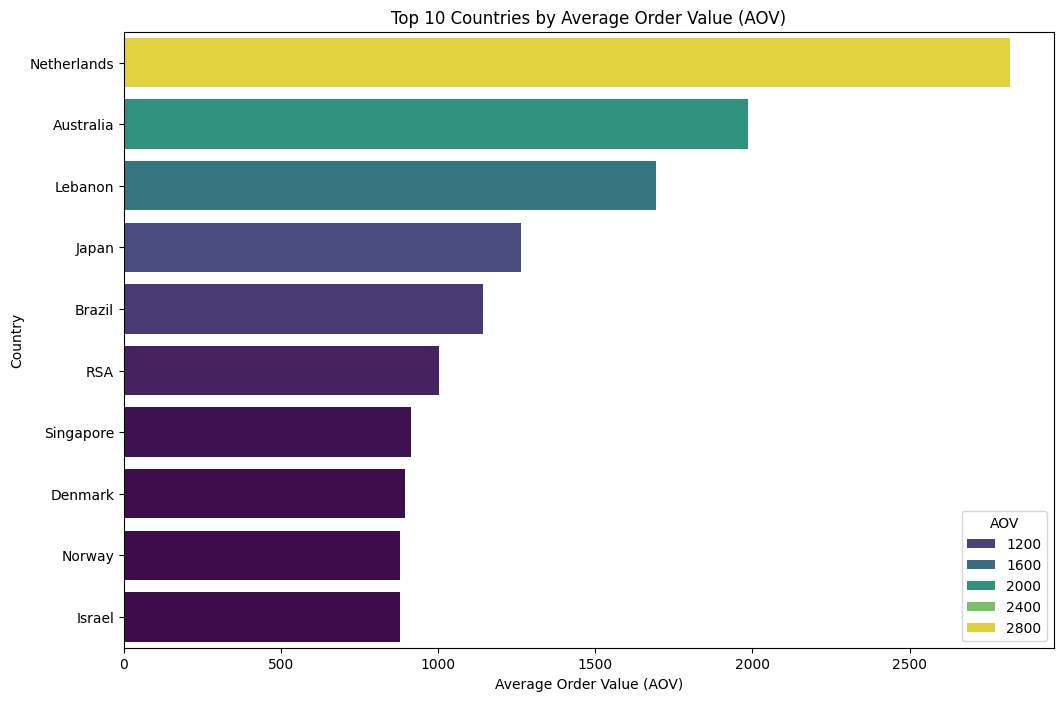

In [45]:
#Ensure proper data types
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'])
# Calculate Total Price for each order
ed['TotalPrice'] = ed['Quantity'] * ed['UnitPrice']
# Aggregate data: Calculate average order value (AOV) per country
country_aov = ed.groupby('Country').agg({'TotalPrice': 'sum', 'InvoiceNo': 'nunique'}).reset_index()
country_aov['AOV'] = country_aov['TotalPrice'] / country_aov['InvoiceNo']
# Sort by AOV for better visualization
country_aov = country_aov.sort_values(by='AOV', ascending=False)

# Display results
print("Average Order Value (AOV) by Country:")
print(country_aov[['Country', 'AOV']])

# Bar plot for AOV by country
plt.figure(figsize=(12, 8))
sns.barplot(data=country_aov.head(10), x='AOV', y='Country', hue='AOV',  palette='viridis')
plt.title('Top 10 Countries by Average Order Value (AOV)')
plt.xlabel('Average Order Value (AOV)')
plt.ylabel('Country')
plt.show()

**6. Payment Analysis:**

- What are the most common payment methods used by customers?

In [47]:
print (ed.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'DayOfWeek', 'Hour', 'TimeDiff',
       'Year', 'Month', 'MonthName', 'DayName', 'Season', 'HoursOfDay',
       'TotalPrice'],
      dtype='object')


There is no column related to payment methods in this dataset. Therefore, it is not possible to determine the most common payment methods used by customers based on the current data.

- Is there a relationship between the payment method and the order amount?

There is no column related to payment methods in this dataset. Therefore, it is not possible to determine the relationship between the payment method and the order amount.

**7. Customer Behavior:**

- How long, on average, do customers remain active (between their first and last purchase)?

Average Active Duration (in days): 99.91


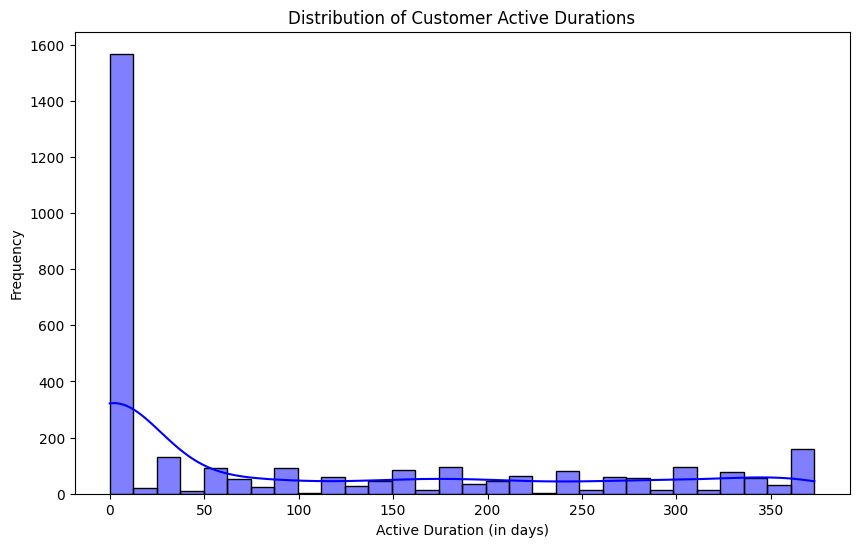

In [48]:
# Ensure InvoiceDate is in datetime format
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'])
# Remove rows with null CustomerID
ed = ed.dropna(subset=['CustomerID'])
# Group by CustomerID to find first and last purchase dates
customer_activity = ed.groupby('CustomerID').agg(
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

# Calculate active duration in days
customer_activity['ActiveDuration'] = (customer_activity['LastPurchase'] - customer_activity['FirstPurchase']).dt.days

# Calculate the average active duration
average_active_duration = customer_activity['ActiveDuration'].mean()

# Display the results
print("Average Active Duration (in days): {:.2f}".format(average_active_duration))
# Plot the distribution of active durations
plt.figure(figsize=(10, 6))
sns.histplot(customer_activity['ActiveDuration'], bins=30, kde=True, color='blue')
plt.title('Distribution of Customer Active Durations')
plt.xlabel('Active Duration (in days)')
plt.ylabel('Frequency')
plt.show()

- Are there any customer segments based on their purchase behavior?

Cluster Summary:
            Recency   Frequency       Monetary  CustomerCount
Cluster                                                      
0        255.657469    3.286394     923.753788           1051
1         43.908954    6.660966    2082.181469           1988
2          2.000000  110.500000  213995.575000              4
3          7.269231   55.711538   32024.793077             52


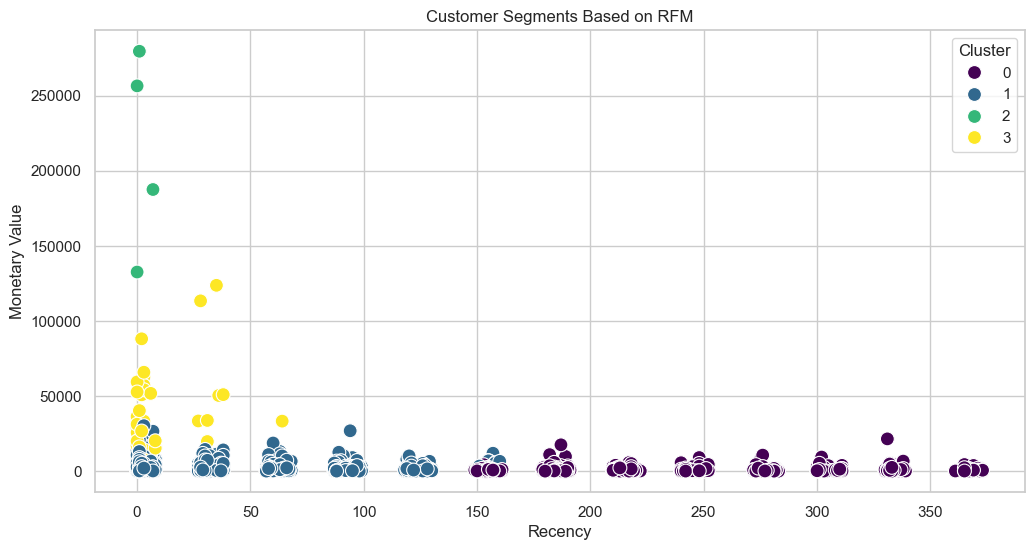

In [49]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ensure InvoiceDate is in datetime format
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'])
# Calculate RFM metrics
reference_date = ed['InvoiceDate'].max()
rfm = ed.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('CustomerID', lambda x: (ed.loc[x.index, 'Quantity'] * ed.loc[x.index, 'UnitPrice']).sum())
).reset_index()
# Remove rows with invalid or zero monetary values
rfm = rfm[rfm['Monetary'] > 0]
# Check and handle missing or invalid values
rfm = rfm.dropna()  # Drop rows with NaN values
rfm = rfm[(rfm[['Recency', 'Frequency', 'Monetary']] >= 0).all(axis=1)]  # Keep non-negative values
# Normalize RFM metrics
scaler = StandardScaler()
rfm_normalized = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_normalized)
# Profile clusters
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'CustomerCount'})

# Display results
print("Cluster Summary:")
print(cluster_summary)
# Visualize clusters
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis', s=100)
plt.title('Customer Segments Based on RFM')
plt.xlabel('Recency')
plt.ylabel('Monetary Value')
plt.show()

**8. Returns and Refunds:**

- What is the percentage of orders that have experienced returns or refunds?

In [50]:
print (ed.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'DayOfWeek', 'Hour', 'TimeDiff',
       'Year', 'Month', 'MonthName', 'DayName', 'Season', 'HoursOfDay',
       'TotalPrice'],
      dtype='object')


There is no column related to returns and refunds in this dataset. Therefore, it is not possible to determine the percentage of orders that have experienced returns or refunds.

- Is there a correlation between the product category and the likelihood of returns?

There is no column related to returns and refunds in this dataset. Therefore, it is not possible to determine the correlation between the product category and the likelihood of returns.

**9. Profitability Analysis:**

- Can you calculate the total profit generated by the company during the dataset's period?

In [51]:
# Ensure InvoiceDate is in datetime format
ed['InvoiceDate'] = pd.to_datetime(ed['InvoiceDate'])
# Calculate the total revenue (Quantity * UnitPrice)
ed['Revenue'] = ed['Quantity'] * ed['UnitPrice']
# Calculate the total profit 
# Assuming gross revenue as profit
total_profit = ed['Revenue'].sum()

# Display the result
print("Total Profit Generated by the Company: {:.2f}".format(total_profit))
# Group by year-month
ed['YearMonth'] = ed['InvoiceDate'].dt.to_period('M')
# Calculate monthly profit
monthly_profit = ed.groupby('YearMonth')['Revenue'].sum().reset_index()
# Display the monthly profit
print("Monthly Profit:")
print(monthly_profit)

Total Profit Generated by the Company: 8300065.81
Monthly Profit:
   YearMonth    Revenue
0    2010-12  353846.32
1    2011-01  199815.27
2    2011-02  163960.71
3    2011-03  203471.87
4    2011-04  180762.84
5    2011-05  260273.17
6    2011-06  234951.42
7    2011-07  183867.84
8    2011-08  281783.39
9    2011-09  276141.56
10   2011-10  395042.51
11   2011-11  450277.23
12   2011-12  342506.38


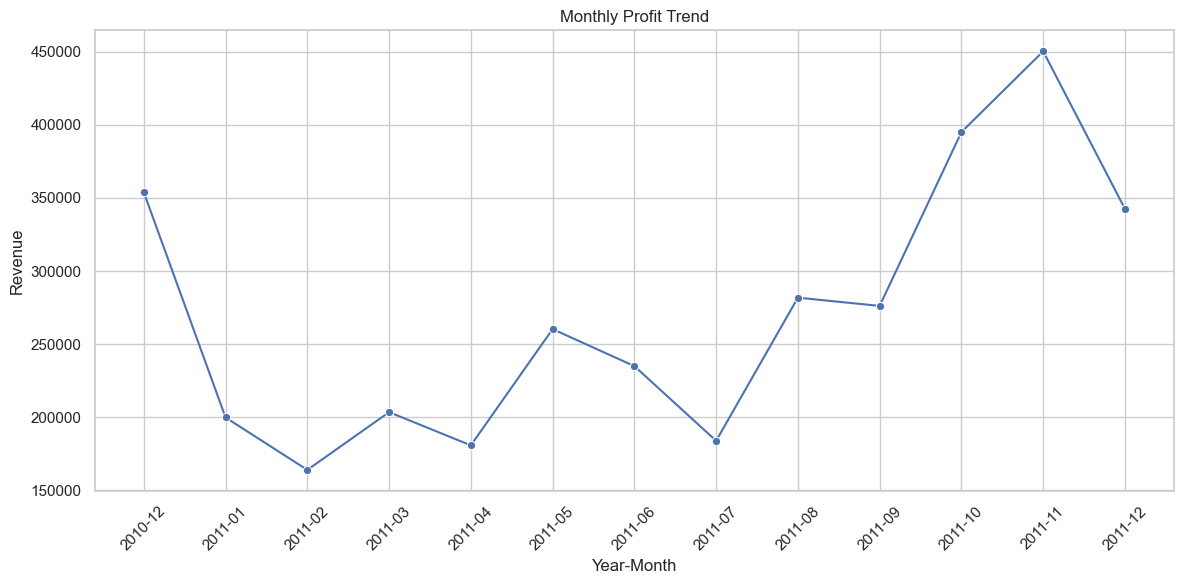

In [52]:
monthly_profit['Revenue'] = pd.to_numeric(monthly_profit['Revenue'], errors='coerce')
monthly_profit = monthly_profit.dropna(subset=['Revenue'])
monthly_profit['YearMonth'] = monthly_profit['YearMonth'].astype(str)
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_profit, x='YearMonth', y='Revenue', marker='o')
plt.title('Monthly Profit Trend')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)  # Rotate x-axis labels for better understanding
plt.tight_layout()
plt.show()

- What are the top 5 products with the highest profit margins?

In [53]:
# Calculate the revenue for each transaction
ed['Revenue'] = ed['Quantity'] * ed['UnitPrice']
# Group by product description and calculate total revenue per product
product_revenue = ed.groupby('Description')['Revenue'].sum()
# Get the top 5 products with the highest revenue
top_5_products = product_revenue.sort_values(ascending=False).head(5)
# Display the results
top_5_products

Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
Name: Revenue, dtype: float64

**10. Customer Satisfaction:**

- Is there any data available on customer feedback or ratings for products or services?

In [54]:
print(ed.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'DayOfWeek', 'Hour', 'TimeDiff',
       'Year', 'Month', 'MonthName', 'DayName', 'Season', 'HoursOfDay',
       'TotalPrice', 'Revenue', 'YearMonth'],
      dtype='object')


There is no column related to customer feedback in this dataset. Therefore, it is not possible to determine the customer feedback or ratings for products or services.

- Can you analyze the sentiment or feedback trends, if available?

There is no column related to feedback trends in this dataset. Therefore, it is not possible to determine the feedback trends.